## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HOANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HOANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HOANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HOANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())


#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [8]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], dayfirst=True)
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [9]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [10]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = customer_data[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

In [11]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = customer_data[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

#### A4. Phân tích EDA

In [12]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4834.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4481.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4661.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4836.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5010.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5180.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

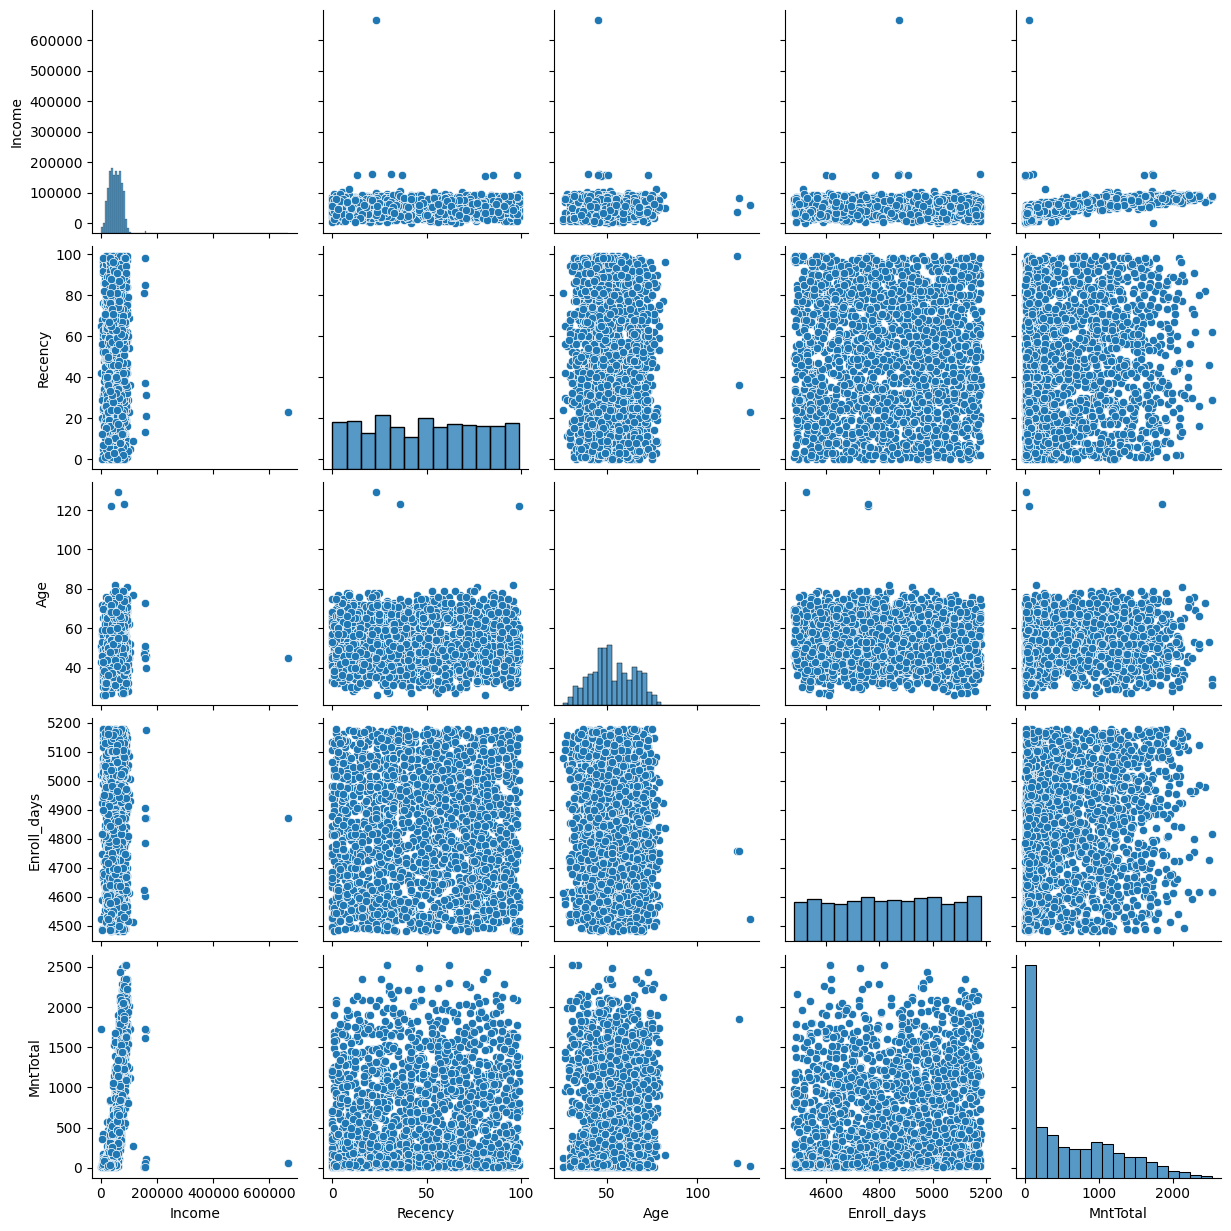

In [14]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [15]:
# TODO - xử lý nhiễu (nếu có)
customer_data = customer_data[(customer_data['Age'] < 100) & (customer_data['Income'] < 600000)]

In [16]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [17]:
# TODO
print(df.select_dtypes(include=['object']).columns.to_list())

[]


**Chuẩn hoá các thuộc tính kiểu số**

In [18]:
# TODO
from sklearn.preprocessing import StandardScaler
df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index)

In [19]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.236000e+03,2.236000e+03,2.236000e+03,2236.000000,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,2.240307e-16,-7.149916e-17,1.271096e-17,0.000000,-7.308803e-17,-1.322734e-16,-1.525315e-16,6.514368e-17,1.150342e-15,2.192641e-16,4.766610e-18
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.346560e+00,-1.696543e+00,-1.203575e+00,-1.470716,-9.110556e-01,-1.783046e+00,-2.192136e+00,-2.316276e+00,-1.750171e+00,-1.758810e+00,-9.987636e-01
25%,-7.688934e-01,-8.675502e-01,-6.861374e-01,-0.751127,-9.110556e-01,-8.600834e-01,-9.557071e-01,-6.924366e-01,-8.559730e-01,-6.565959e-01,-8.924037e-01
50%,-1.298227e-02,-4.016436e-03,-1.686996e-01,-0.031538,-2.268842e-01,-2.447750e-01,2.807217e-01,-9.417994e-02,1.101605e-02,4.456177e-01,-3.481402e-01
75%,7.620935e-01,8.595173e-01,3.487383e-01,0.688050,4.572872e-01,6.781877e-01,6.928646e-01,8.459377e-01,8.668740e-01,4.456177e-01,7.304157e-01
max,5.158923e+00,1.723051e+00,6.557993e+00,8.243731,8.667344e+00,2.216459e+00,6.050723e+00,2.469777e+00,1.707891e+00,2.650045e+00,3.189157e+00


#### A6. Phân cụm KMeans

In [20]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

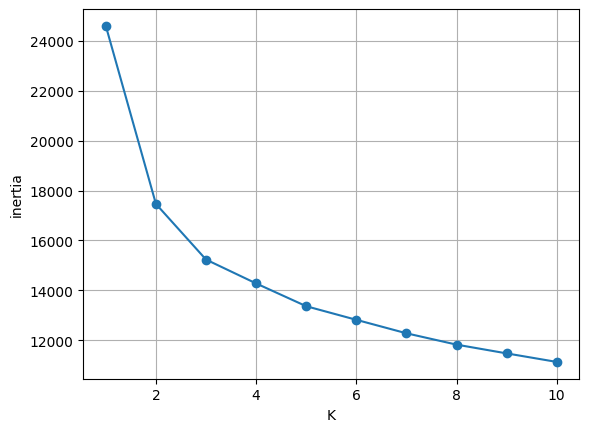

In [21]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init=20, random_state=99).fit(df).inertia_ for k in ks]
plt.plot(ks, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('inertia')
plt.grid(True)
plt.show()


Sử dụng thư viện yellowbrick

In [22]:
%pip install setuptools

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HOANG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
from yellowbrick.cluster import KElbowVisualizer

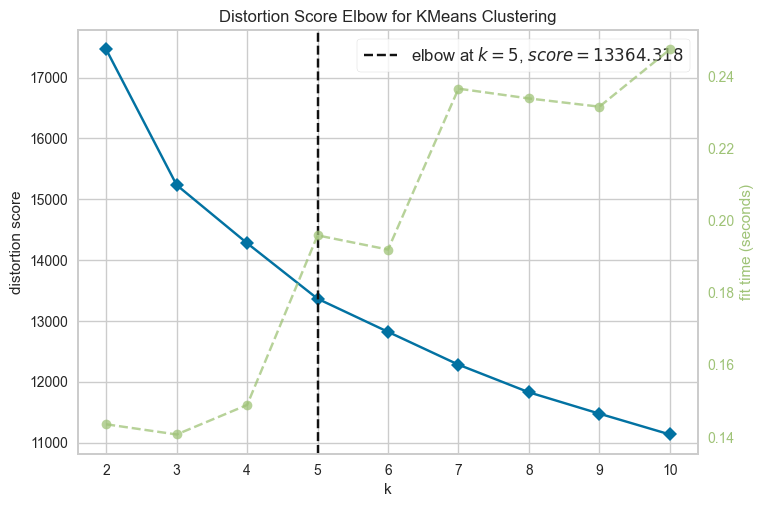

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [24]:
# TODO
KMeans._estimator_type = 'clusterer'
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model ,k=10)
visualizer.fit(df)
visualizer.show()


**Phân cụm từ kết quả của phương pháp Elbow**

In [25]:
# TODO
kmean = KMeans(n_clusters=visualizer.elbow_value_, n_init=20, random_state=99).fit(df)

**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [26]:
from sklearn.decomposition import PCA

In [27]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
pca = PCA()
pca_scores = pca.fit_transform(df)
scores_2d = pca_scores[:, :2]

**Trực quan hoá kết quả phân cụm**

In [28]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

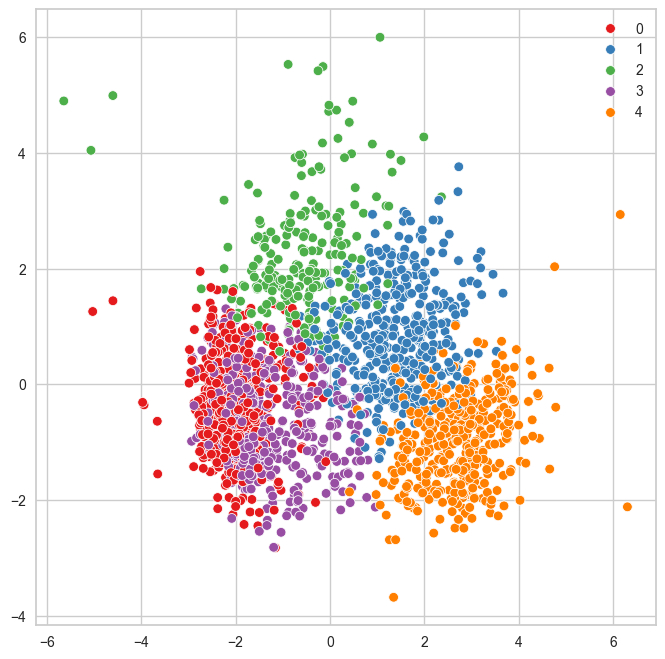

In [29]:
visualize_cluster_result(scores_2d, kmean.labels_)

#### Phân tích kết quả phân cụm (KMeans)

In [30]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5144,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4594,3,0,27,3
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4793,2,0,776,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4620,3,0,53,0
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4642,3,0,422,2


In [31]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

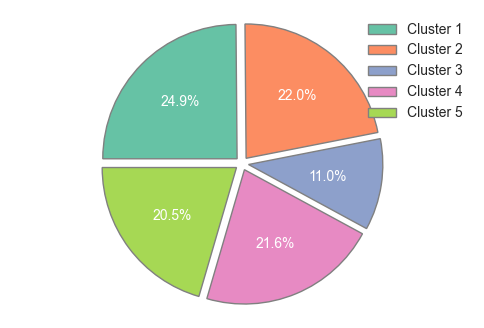

In [32]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

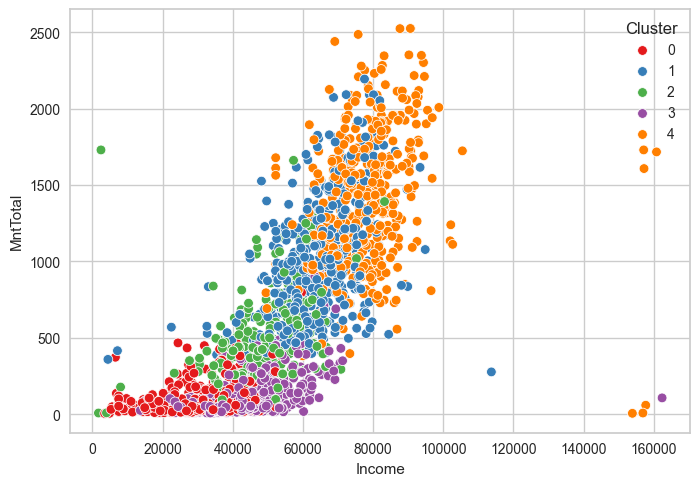

In [33]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

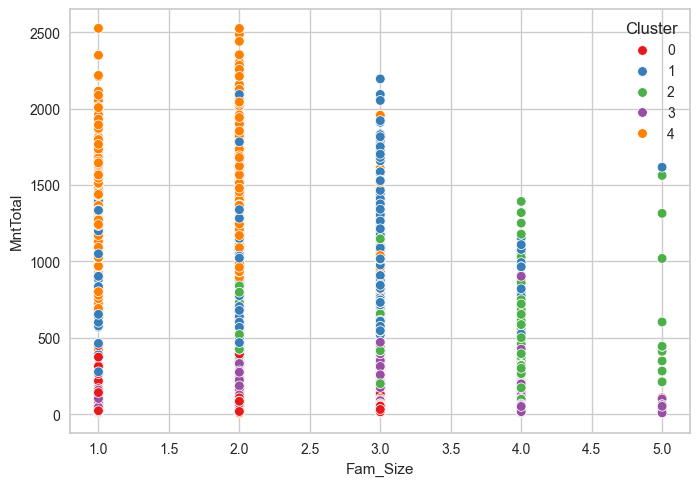

In [34]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
sns.scatterplot(data=kmean_df, x='Fam_Size', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

**Phân tích danh mục mua hàng**

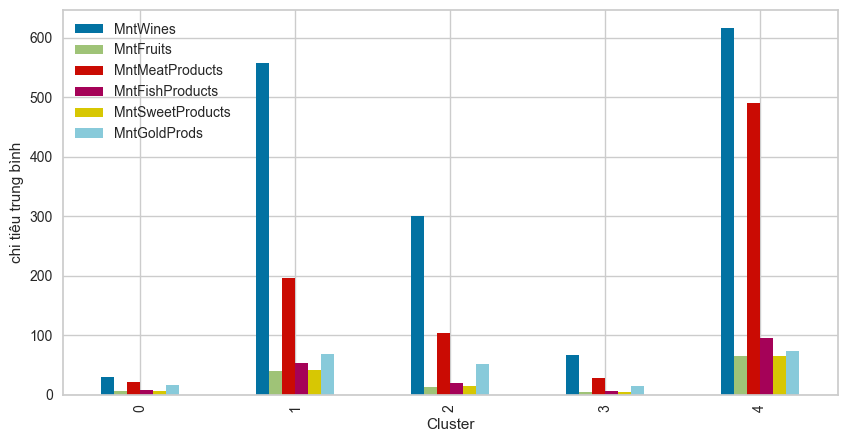

In [35]:
# TODO
cat_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
kmean_df.groupby('Cluster')[cat_cols].mean().plot(kind='bar', figsize=(10,5))
plt.ylabel('chi tiêu trung bình')
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [36]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

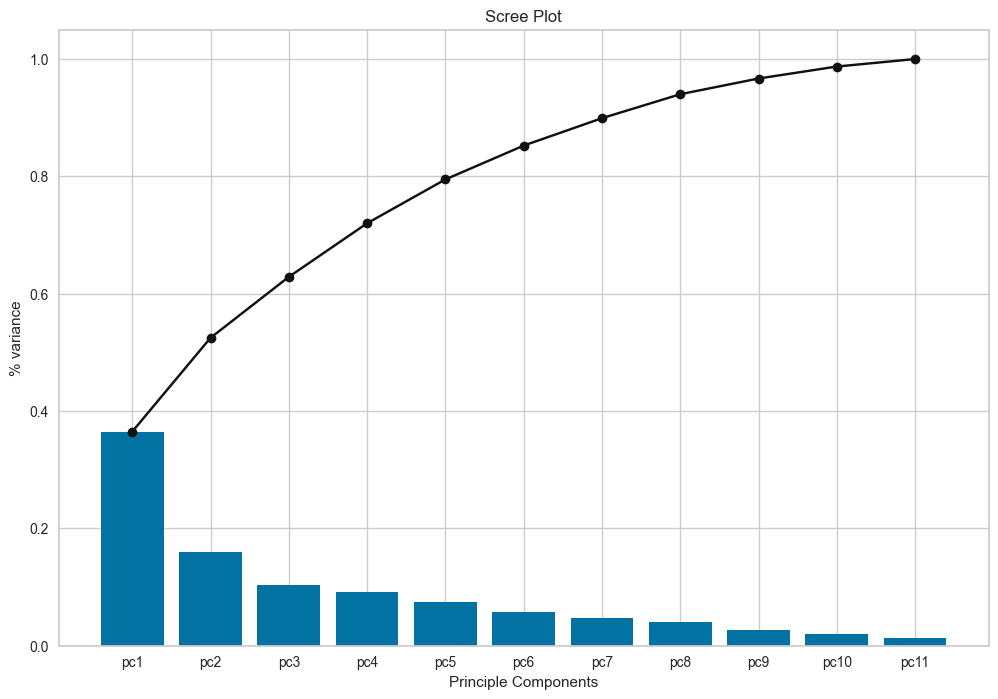

In [37]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [38]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca_transformed_4d = PCA(n_components=4).fit_transform(df)

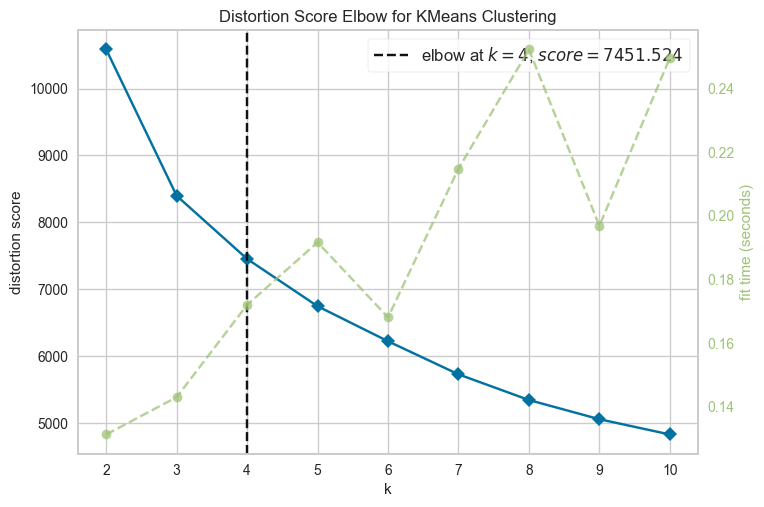

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()

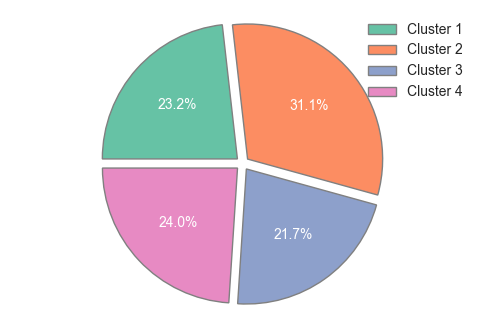

In [40]:
kmean = KMeans(n_clusters=visualizer.elbow_value_, n_init=20, random_state=99).fit(pca_transformed_4d)
visualize_cluster_distribution(kmean.labels_)

In [41]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5144,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4594,3,0,27,0
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4793,2,0,776,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4620,3,0,53,3
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4642,3,0,422,2


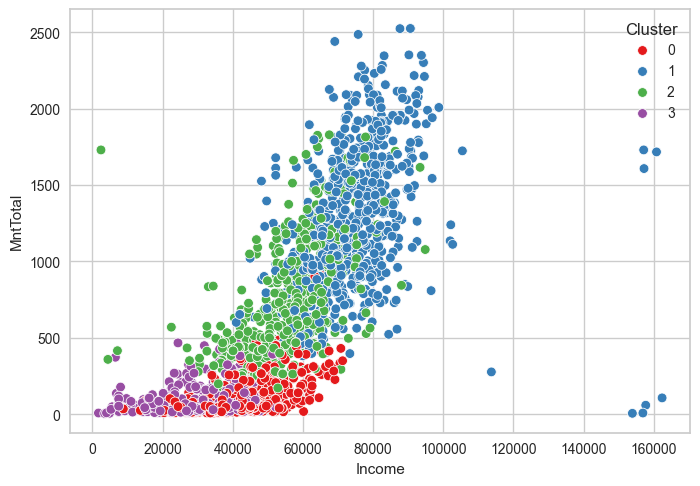

In [42]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [43]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [44]:
len(df.columns)

11

In [45]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [46]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [47]:
import pandas as pd

In [48]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


In [49]:
df = df.dropna(subset=['LAT', 'LON']).reset_index(drop=True)

**Biểu diễn giá trị toạ độ trên bản đồ**

In [50]:
import folium, re

In [51]:
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=10)

In [52]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

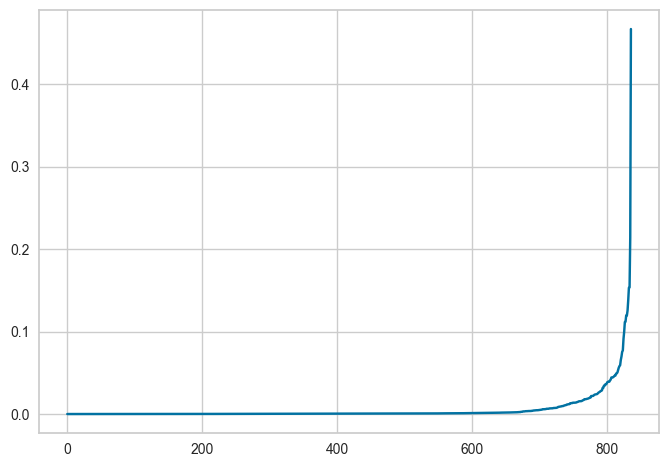

In [53]:
# Knee plot để ước lượng eps
knee_plot(5, X)
plt.show()

In [54]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [55]:
# Sử dụng DBSCAN để phân cụm
eps = 0.02
db = DBSCAN(eps=eps, min_samples=5).fit(X)
df['Cluster'] = db.labels_
df['Color'] = df['Cluster'].apply(lambda c: 'black' if c == -1 else colors[c])

In [56]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='OpenStreetMap',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m

In [57]:
create_map('Cluster', 'Color', 'DBSCAN eps =0.02, min_samples=5')

DBSCAN eps =0.02, min_samples=5
